# Imports

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [153]:
df=pd.read_csv("chess_openings.csv")
df.shape

(1884, 26)

# Initial Look

In [154]:
df.head()

,Unnamed: 0,Opening,Colour,Num Games,ECO,Last Played,Perf Rating,Avg Player,Player Win %,Draw %,...,move2b,move3w,move3b,move4w,move4b,White_win%,Black_win%,White_odds,White_Wins,Black_Wins
0,0,"Alekhine Defense, Balogh Variation",white,692,B03,2018-06-22,2247,2225,40.8,24.3,...,Nd5,d4,d6,Bc4,NaN,40.8,35.0,1.165714,282.336,242.200
1,1,"Alekhine Defense, Brooklyn Variation",black,228,B02,2018-06-27,2145,2193,29.8,22.4,...,Ng8,NaN,NaN,NaN,NaN,47.8,29.8,1.604027,108.984,67.944
2,2,"Alekhine Defense, Exchange Variation",white,6485,B03,2018-07-06,2244,2194,40.8,27.7,...,Nd5,d4,d6,c4,Nb6,40.8,31.5,1.295238,2645.880,2042.775
3,3,"Alekhine Defense, Four Pawns Attack",white,881,B03,2018-06-20,2187,2130,39.7,23.2,...,Nd5,d4,d6,c4,Nb6,39.7,37.1,1.070081,349.757,326.851
4,4,"Alekhine Defense, Four Pawns Attack, Fianchett...",black,259,B03,2018-05-20,2122,2178,37.8,21.2,...,Nd5,d4,d6,c4,Nb6,40.9,37.8,1.082011,105.931,97.902


In [155]:
df.describe()

,Unnamed: 0,Num Games,Perf Rating,Avg Player,Player Win %,Draw %,Opponent Win %,White_win%,Black_win%,White_odds,White_Wins,Black_Wins
count,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000
mean,941.500000,1846.019108,2235.945860,2236.531847,35.159395,29.914066,34.928715,39.745701,30.342410,1.448725,708.835970,557.051955
std,544.008272,2739.103462,135.260392,127.723711,9.077139,8.043043,9.180450,7.671108,7.976305,0.673991,1037.027669,866.788831
min,0.000000,100.000000,1583.000000,1577.000000,7.500000,4.000000,6.700000,13.600000,6.700000,0.308642,21.000000,8.946000
25%,470.750000,314.750000,2157.000000,2166.000000,28.900000,24.500000,28.900000,34.800000,25.100000,1.037277,124.740500,91.026250
50%,941.500000,788.500000,2252.500000,2255.000000,35.100000,29.400000,34.650000,39.100000,29.900000,1.325008,310.274000,230.952000
75%,1412.250000,2225.000000,2329.000000,2326.000000,41.125000,34.625000,40.525000,44.000000,35.000000,1.674116,824.243000,651.262750
max,1883.000000,22482.000000,2536.000000,2492.000000,77.600000,68.500000,77.500000,77.600000,64.800000,9.810127,8295.858000,8700.534000


# Exploratory Data Analysis and Data Visualization

In [156]:
df[['Opening', 'Num Games']].sort_values(by='Num Games', ascending=False).reset_index(drop=True).head(10)

,Opening,Num Games
0,"Sicilian Defense, Closed Variation",22482
1,"Zukertort Opening, Sicilian Invitation",20045
2,"Sicilian Defense, Alapin Variation, General",19885
3,"King's Indian Attack, General",19835
4,"Pirc Defense, General",18659
5,"Trompowsky Attack, General",17885
6,"Sicilian Defense, Nyezhmetdinov-Rossolimo Attack",17184
7,"Indian Game, General",16580
8,"French Defense, Exchange Variation",16163
9,"Sicilian Defense, Old Sicilian, General",16093


<Axes: xlabel='Perf Rating', ylabel='Player Win %'>

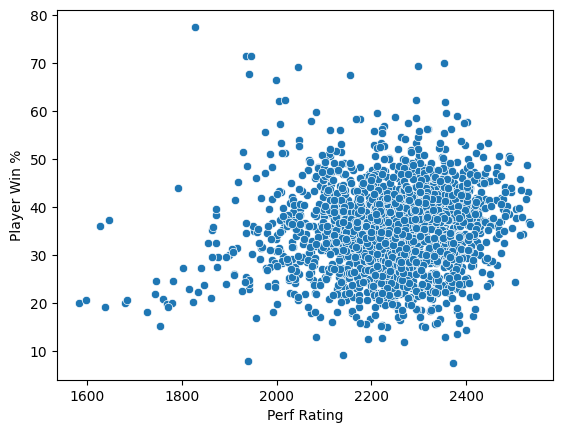

In [157]:
sns.scatterplot(x='Perf Rating', y='Player Win %', data=df)

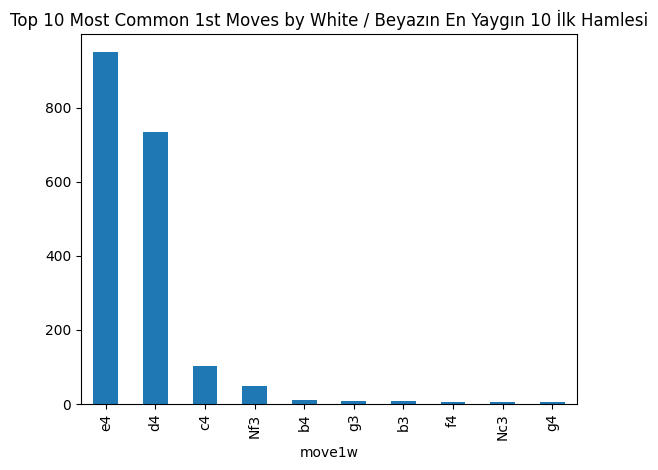

In [158]:
df['move1w'].value_counts().head(10).plot(kind='bar', title='Top 10 Most Common 1st Moves by White / Beyazın En Yaygın 10 İlk Hamlesi');

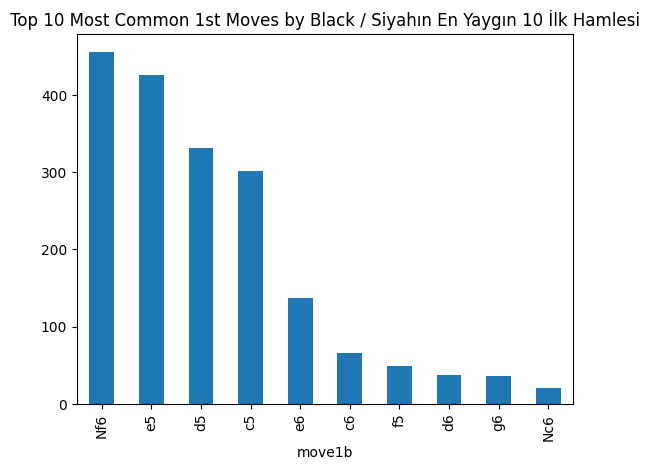

In [159]:
df['move1b'].value_counts().head(10).plot(kind='bar', title='Top 10 Most Common 1st Moves by Black / Siyahın En Yaygın 10 İlk Hamlesi');

In [160]:
sicilian_df = df[df['Opening'].str.contains("Sicilian", case=False)]

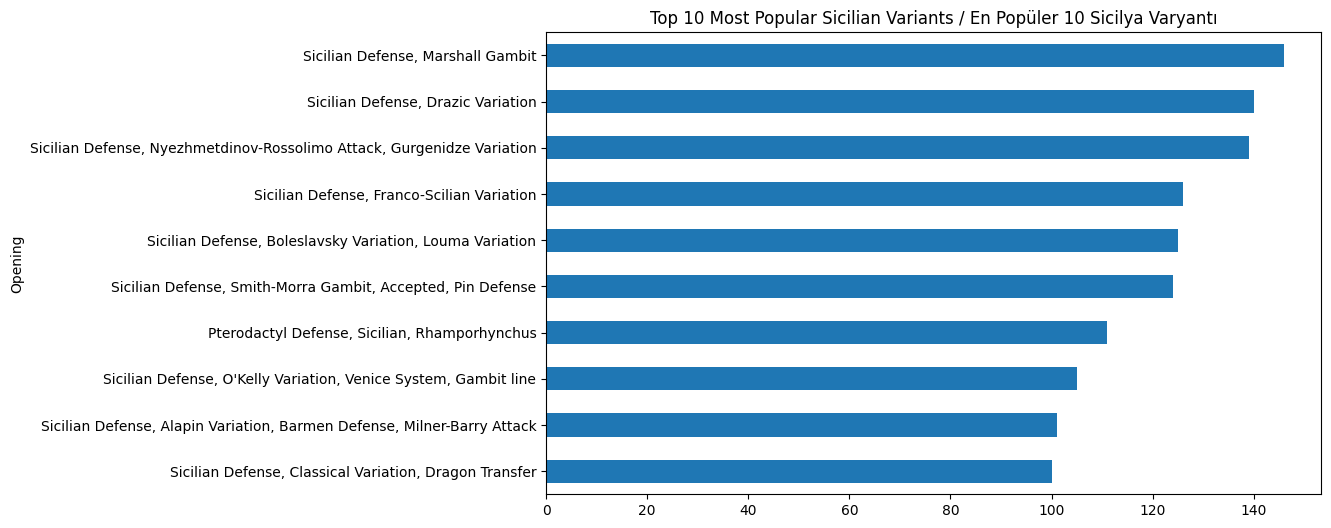

In [161]:
sicilian_df.groupby('Opening')['Num Games'].sum().sort_values(ascending=True).head(10).plot(
    kind='barh', title='Top 10 Most Popular Sicilian Variants / En Popüler 10 Sicilya Varyantı', figsize=(10,6));

In [162]:
najdorf_df = df[df['Opening'].str.contains("Najdorf", case=False)]
najdorf_df.shape

(24, 26)

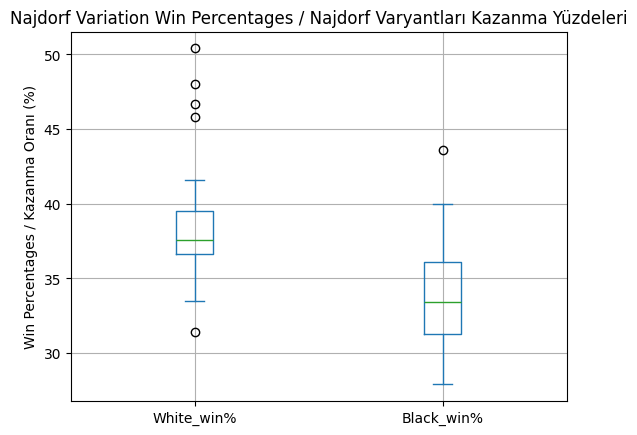

In [163]:
najdorf_df[['White_win%', 'Black_win%']].plot(kind='box')
plt.title('Najdorf Variation Win Percentages / Najdorf Varyantları Kazanma Yüzdeleri')
plt.ylabel('Win Percentages / Kazanma Oranı (%)')
plt.grid(True)
plt.show()

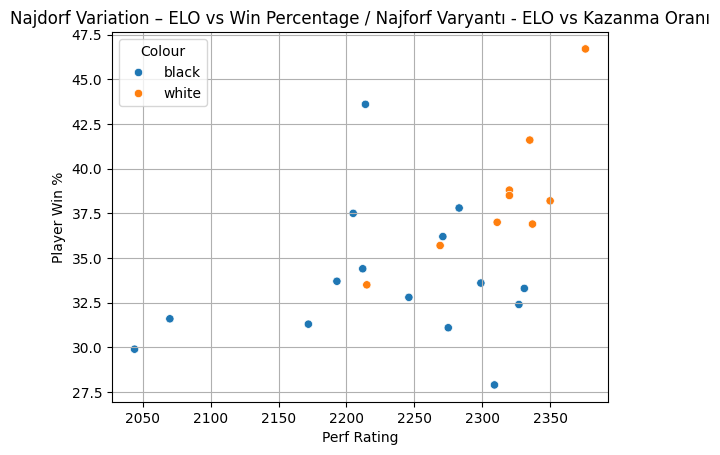

In [164]:
sns.scatterplot(data=najdorf_df, x='Perf Rating', y='Player Win %', hue='Colour')
plt.title('Najdorf Variation – ELO vs Win Percentage / Najforf Varyantı - ELO vs Kazanma Oranı')
plt.grid(True)
plt.show()

In [165]:
alekhine_df = df[df['Opening'].str.contains("Alekhine", case=False)]
alekhine_df.shape

(53, 26)

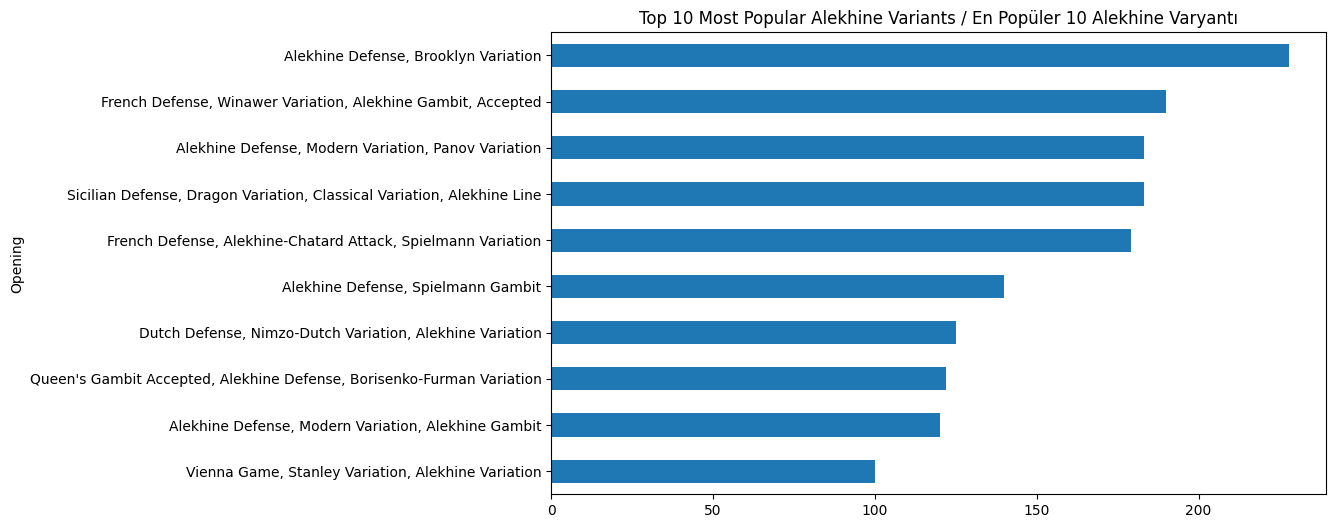

In [166]:
alekhine_df.groupby('Opening')['Num Games'].sum().sort_values(ascending=True).head(10).plot(
    kind='barh', title='Top 10 Most Popular Alekhine Variants / En Popüler 10 Alekhine Varyantı', figsize=(10,6));

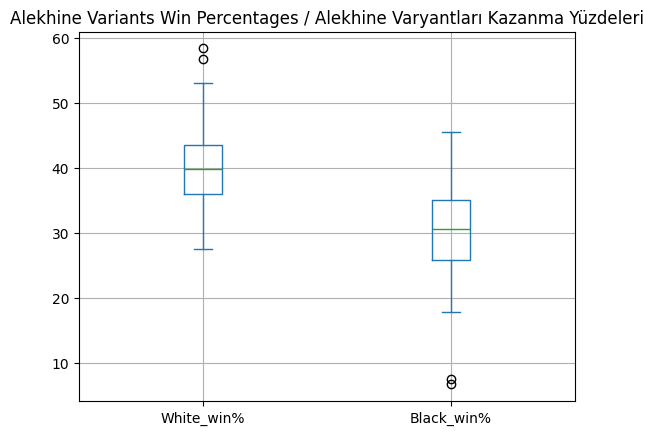

In [167]:
alekhine_df[['White_win%', 'Black_win%']].plot(kind='box',grid=True,title='Alekhine Variants Win Percentages / Alekhine Varyantları Kazanma Yüzdeleri');

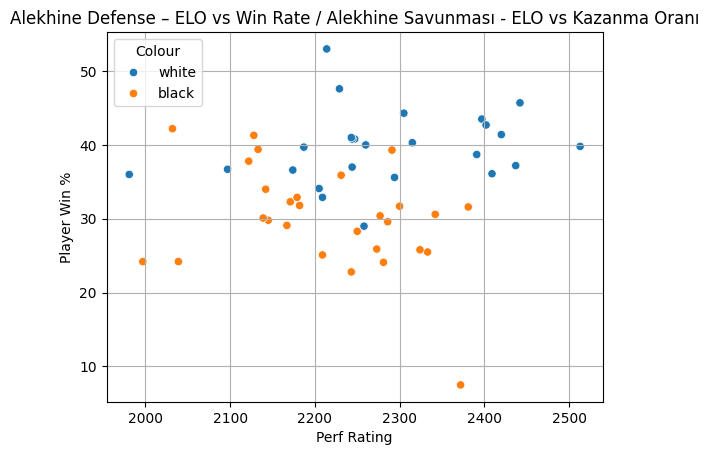

In [168]:
sns.scatterplot(data=alekhine_df, x='Perf Rating', y='Player Win %', hue='Colour')
plt.title('Alekhine Defense – ELO vs Win Rate / Alekhine Savunması - ELO vs Kazanma Oranı')
plt.grid(True)
plt.show()

In [169]:
top_white = df[['Opening', 'White_Wins']].sort_values(by='White_Wins', ascending=False).head(10)
top_black = df[['Opening', 'Black_Wins']].sort_values(by='Black_Wins', ascending=False).head(10)

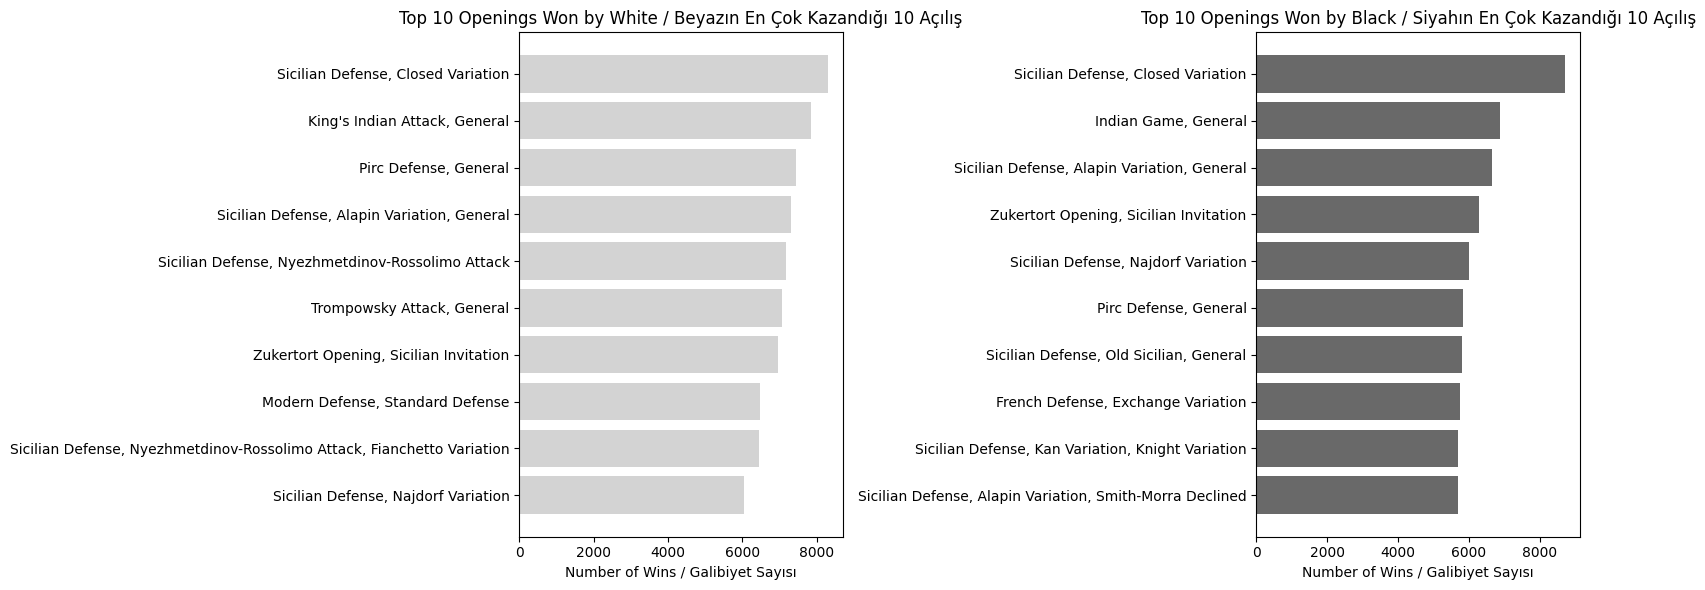

In [170]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].barh(top_white['Opening'], top_white['White_Wins'], color='lightgray')
axs[0].set_title("Top 10 Openings Won by White / Beyazın En Çok Kazandığı 10 Açılış")
axs[0].invert_yaxis()
axs[0].set_xlabel("Number of Wins / Galibiyet Sayısı")

axs[1].barh(top_black['Opening'], top_black['Black_Wins'], color='dimgray')
axs[1].set_title("Top 10 Openings Won by Black / Siyahın En Çok Kazandığı 10 Açılış")
axs[1].invert_yaxis()
axs[1].set_xlabel("Number of Wins / Galibiyet Sayısı")

plt.tight_layout()
plt.show()